In [11]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [12]:
# Load data
path = kagglehub.dataset_download("shwetabh123/mall-customers")
df = pd.read_csv(path + "/Mall_Customers.csv")


Using Colab cache for faster access to the 'mall-customers' dataset.


In [13]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [15]:
# Preprocessing
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

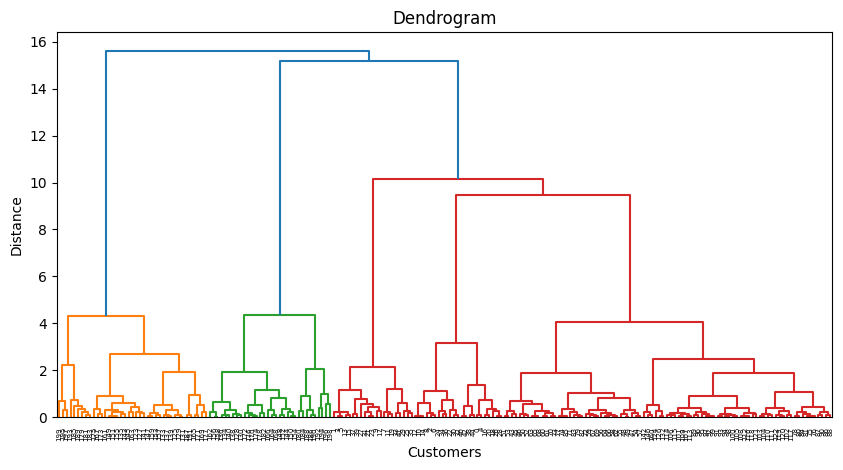

In [16]:
# Dendrogram
plt.figure(figsize=(10, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [17]:
# Clustering (cut into 5 clusters based on dendrogram)
labels = fcluster(linked, t=5, criterion='maxclust')

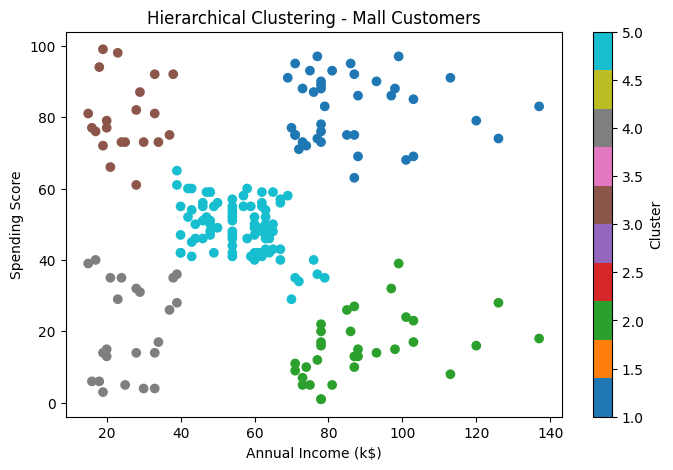

In [18]:
# Visualisation
plt.figure(figsize=(8, 5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=labels, cmap='tab10')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering - Mall Customers")
plt.colorbar(label='Cluster')
plt.show()

In [19]:
# Accuracy (Silhouette Score)
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5538
